In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
abhishekbuddiga06_embryo_dataset_path = kagglehub.dataset_download('abhishekbuddiga06/embryo-dataset')

print('Data source import complete.')


In [ ]:
import os
print(os.listdir('/kaggle/input'))

['datasets']


In [ ]:
import os
print(os.listdir('/kaggle/input/datasets'))

['abhishekbuddiga06']


In [ ]:
import os

BASE_DIR = '/kaggle/input/datasets/abhishekbuddiga06'
SAVE_DIR = '/kaggle/working/'

print("Folders found:", os.listdir(BASE_DIR))

Folders found: ['embryo-dataset']


In [ ]:
import os

BASE_DIR = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset'
SAVE_DIR = '/kaggle/working/'

print("Actual data content:", os.listdir(BASE_DIR))

Actual data content: ['embryo_dataset', 'embryo_dataset_annotations']


In [ ]:
import os

BASE_DIR = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset'
SAVE_DIR = '/kaggle/working/'

print("Final check - folders inside:", os.listdir(BASE_DIR))


Final check - folders inside: ['embryo_dataset']


Assignment 5: Embryo Stage Classification with LSTM

Deep Learning for Medical Image Processing

Task: 16-class embryo development stage classification using sequence-aware LSTM

Key difference from Assignment 4: Instead of classifying individual frames independently, we now classify sequences of 5 consecutive frames — the LSTM leverages temporal ordering.

Why LSTM for this problem?

Embryo development is a strictly ordered temporal process. A frame showing 4 cells never appears before a frame showing 2 cells in the same video. LSTM captures this ordering within a local window of frames, making predictions that are temporally consistent.

In [ ]:
!pip install -q kaggle tensorflow matplotlib seaborn scikit-learn pandas numpy opencv-python-headless tqdm
print('All packages installed!')

All packages installed!


In [ ]:
import os, re, json, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print(f'TensorFlow : {tf.__version__}')

try:
    strategy = tf.distribute.MirroredStrategy()
    print(f'GPUs Available: {strategy.num_replicas_in_sync}')
except AttributeError:
    print("Strategy error: Falling back to default.")
    strategy = tf.distribute.get_strategy()

# Hyperparameters
NUM_CLASSES   = 16
SEQ_LEN       = 5
IMG_H, IMG_W  = 112, 112
BATCH_SIZE    = 32
EPOCHS        = 30
LEARNING_RATE = 1e-4
LSTM_UNITS    = 256
DROPOUT_RATE  = 0.4
SEED          = 42

# Custom loss weights
LAMBDA1  = 0.5
LAMBDA2  = 0.3
DELTA    = 3
ALPHA_PL = 1.0
BETA_PL  = 2.0

# 16 ordered phase labels
PHASE_LABELS = [
    'pPB2','pPNa','pPNf','p2','p3','p4','p5','p6',
    'p7','p8','p9+','pM','pSB','pB','pEB','pHB'
]
LABEL2IDX = {p: i for i, p in enumerate(PHASE_LABELS)}
IDX2LABEL = {i: p for i, p in enumerate(PHASE_LABELS)}

# Mapping
EVENT_TO_PHASE = {
    'tPB2':'pPB2','tPNa':'pPNa','tPNf':'pPNf',
    't2':'p2','t3':'p3','t4':'p4','t5':'p5','t6':'p6',
    't7':'p7','t8':'p8','t9+':'p9+','tM':'pM',
    'tSB':'pSB','tB':'pB','tEB':'pEB','tHB':'pHB',
    'pPB2':'pPB2','pPNa':'pPNa','pPNf':'pPNf',
    'p2':'p2','p3':'p3','p4':'p4','p5':'p5','p6':'p6',
    'p7':'p7','p8':'p8','p9+':'p9+','pM':'pM',
    'pSB':'pSB','pB':'pB','pEB':'pEB','pHB':'pHB',
}

np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT       = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset'
IMAGES_DIR      = os.path.join(DATA_ROOT, 'embryo_dataset')
ANNOTATIONS_DIR = os.path.join(DATA_ROOT, 'embryo_dataset_annotations')
SAVE_DIR        = '/kaggle/working/results'

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

print(f'\nKaggle Config Active:')
print(f'  DATA_ROOT     : {DATA_ROOT}')
print(f'  SAVE_DIR      : {SAVE_DIR}')
print(f'  SEQ_LEN       : {SEQ_LEN}')
print(f'  BATCH_SIZE    : {BATCH_SIZE}')

TensorFlow : 2.19.0
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
GPUs Available: 2

Kaggle Config Active:
  DATA_ROOT     : /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset
  SAVE_DIR      : /kaggle/working/results
  SEQ_LEN       : 5
  BATCH_SIZE    : 32


In [ ]:
if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR, exist_ok=True)

print(f'Kaggle session ready.')
print(f'Results will be saved to: {SAVE_DIR}')

Kaggle session ready.
Results will be saved to: /kaggle/working/results


In [ ]:
import os
check_path = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset'
if os.path.exists(check_path):
    print("Data is already here! No download needed.")
    print("Folders found:", os.listdir(check_path))
else:
    print("Path not found. Check the spelling or if the data is attached.")

Data is already here! No download needed.
Folders found: ['embryo_dataset']


In [ ]:
# STEP: AUTO-DETECTING DIRECTORIES

focal_markers = ['f-45','f-30','f-15','f15','f30','f45']

SEARCH_ROOT = '/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset'

IMAGES_DIR = None
for root, dirs, files in os.walk(SEARCH_ROOT):
    name_low = os.path.basename(root).lower()

    if 'embryo_dataset' not in name_low: continue
    if 'annotation' in name_low: continue
    if any(m in name_low for m in focal_markers): continue

    subdirs = [d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]
    if len(subdirs) >= 100:
        IMAGES_DIR = root
        break

ANNOTATIONS_DIR = None
for root, dirs, files in os.walk(SEARCH_ROOT):
    if sum(1 for f in files if f.endswith('.csv')) >= 100:
        ANNOTATIONS_DIR = root
        break

if IMAGES_DIR is None:
    IMAGES_DIR = os.path.join(SEARCH_ROOT, 'embryo_dataset', 'embryo_dataset')
if ANNOTATIONS_DIR is None:
    ANNOTATIONS_DIR = os.path.join(SEARCH_ROOT, 'embryo_dataset_annotations', 'embryo_dataset_annotations')

print(f'IMAGES_DIR      = {IMAGES_DIR}')
print(f'ANNOTATIONS_DIR = {ANNOTATIONS_DIR}')

# Verification
assert os.path.isdir(IMAGES_DIR), f"Images directory not found at {IMAGES_DIR}"
assert os.path.isdir(ANNOTATIONS_DIR), f"Annotations directory not found at {ANNOTATIONS_DIR}"

embryo_folders = [f for f in os.listdir(IMAGES_DIR) if os.path.isdir(os.path.join(IMAGES_DIR, f))]
csv_files      = [f for f in os.listdir(ANNOTATIONS_DIR) if f.endswith('.csv')]
print(f'Embryo folders  : {len(embryo_folders)}  (expect ~704)')
print(f'Annotation CSVs : {len(csv_files)}    (expect ~704)')

# Peek at one embryo
sample_dir  = os.path.join(IMAGES_DIR, sorted(embryo_folders)[0])
sample_imgs = sorted(os.listdir(sample_dir))
print(f'\nSample embryo   : {os.path.basename(sample_dir)}')
print(f'Frame count     : {len(sample_imgs)}')
print(f'First 3 files   : {sample_imgs[:3]}')
print('\n Paths verified on Kaggle!')

IMAGES_DIR      = /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset
ANNOTATIONS_DIR = /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations
Embryo folders  : 704  (expect ~704)
Annotation CSVs : 704    (expect ~704)

Sample embryo   : AA83-7
Frame count     : 285
First 3 files   : ['D2013.01.28_S0717_I132_WELL7_RUN1.jpeg', 'D2013.01.28_S0717_I132_WELL7_RUN10.jpeg', 'D2013.01.28_S0717_I132_WELL7_RUN100.jpeg']

 Paths verified on Kaggle!


In [ ]:
# STEP: PARSING ANNOTATIONS

def natural_sort_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split('([0-9]+)', s)]

def parse_annotations_for_lstm(annotations_dir, images_dir):
    """
    Returns a dict: embryo_id → list of frame dicts, sorted by frame_idx.

    Each frame dict: {frame_idx, image_path, label_idx, label_str}

    IMPORTANT rules taken into consideration for LSTM:
    - Frames are in strict temporal order within each embryo
    - NO frames are deleted (only unlabeled frames before tPB2 are excluded)
    - Embryos with < SEQ_LEN labeled frames are dropped (can't form even one sequence)
    """
    embryo_sequences = {}
    n_nodir = n_nodata = n_short = 0

    csv_files = sorted([f for f in os.listdir(annotations_dir) if f.endswith('.csv')])
    print(f'Parsing {len(csv_files)} CSV files...')

    for csv_file in tqdm(csv_files, desc='Parsing CSVs'):
        embryo_id = csv_file.replace('_phases.csv', '').replace('.csv', '')
        csv_path  = os.path.join(annotations_dir, csv_file)
        img_dir   = os.path.join(images_dir, embryo_id)

        if not os.path.isdir(img_dir):
            n_nodir += 1
            continue

        # building frame_index → phase mapping from CSV
        frame_label = {}
        try:
            with open(csv_path) as f:
                for line in f:
                    parts = line.strip().replace(',', ' ').split()
                    if len(parts) >= 3:
                        phase = EVENT_TO_PHASE.get(parts[0].strip())
                        if phase:
                            start, end = int(parts[1]), int(parts[2])
                            for fi in range(start, end + 1):
                                frame_label[fi] = phase
        except:
            n_nodata += 1
            continue

        if not frame_label:
            n_nodata += 1
            continue

        # building ordered frame list for this embryo
        # natural sort preserves RUN1 < RUN2 < ... < RUN10 order
        img_files = sorted(
            [f for f in os.listdir(img_dir)
             if f.lower().endswith(('.jpg','.jpeg','.png'))],
            key=natural_sort_key
        )

        frames = []
        for img_file in img_files:
            match = re.search(r'RUN(\d+)', img_file)
            if not match:
                continue
            frame_idx = int(match.group(1))
            phase = frame_label.get(frame_idx)
            if phase is None:
                continue
            frames.append({
                'frame_idx' : frame_idx,
                'image_path': os.path.join(img_dir, img_file),
                'label_idx' : LABEL2IDX[phase],
                'label_str' : phase,
            })

        # dropping out embryos that are too short to form even one sequence
        if len(frames) < SEQ_LEN:
            n_short += 1
            continue

        embryo_sequences[embryo_id] = sorted(frames, key=lambda x: x['frame_idx'])

    n_total  = sum(len(v) for v in embryo_sequences.values())
    n_seqs   = sum(len(v) - SEQ_LEN + 1 for v in embryo_sequences.values())
    print(f'\n  Embryos parsed      : {len(embryo_sequences)}')
    print(f'  Total labeled frames: {n_total:,}')
    print(f'  Total sequences     : {n_seqs:,}  (sliding window, step=1)')
    print(f'  Dropped (no dir)    : {n_nodir}')
    print(f'  Dropped (no data)   : {n_nodata}')
    print(f'  Dropped (too short) : {n_short}')
    return embryo_sequences

embryo_sequences = parse_annotations_for_lstm(ANNOTATIONS_DIR, IMAGES_DIR)

# one example embryo sequence
sample_eid = sorted(embryo_sequences.keys())[0]
sample_seq = embryo_sequences[sample_eid]
print(f'\nExample embryo: {sample_eid}')
print(f'Total frames  : {len(sample_seq)}')
print(f'First 3 frames: ')
for f in sample_seq[:3]:
    print(f'  RUN{f["frame_idx"]:>4}  →  {f["label_str"]}  ({f["label_idx"]})')
print(f'Last 3 frames: ')
for f in sample_seq[-3:]:
    print(f'  RUN{f["frame_idx"]:>4}  →  {f["label_str"]}  ({f["label_idx"]})')

Parsing 704 CSV files...


Parsing CSVs: 100%|██████████| 704/704 [00:07<00:00, 94.12it/s] 


  Embryos parsed      : 704
  Total labeled frames: 297,428
  Total sequences     : 294,612  (sliding window, step=1)
  Dropped (no dir)    : 0
  Dropped (no data)   : 0
  Dropped (too short) : 0

Example embryo: AA83-7
Total frames  : 281
First 3 frames: 
  RUN   5  →  pPB2  (0)
  RUN   6  →  pPB2  (0)
  RUN   7  →  pPB2  (0)
Last 3 frames: 
  RUN 283  →  p8  (9)
  RUN 284  →  p8  (9)
  RUN 285  →  p8  (9)


In [ ]:
# STEP: CORRUPT IMAGE SCAN

print('Scanning for corrupt/unreadable images...')
corrupt_embryos = set()

for embryo_id, frames in tqdm(embryo_sequences.items(), desc='Scanning'):
    for frame in frames:
        path = frame['image_path']
        # size check first
        if not os.path.exists(path) or os.path.getsize(path) == 0:
            corrupt_embryos.add(embryo_id)
            break
        # deep JPEG decode check
        try:
            raw = tf.io.read_file(path)
            tf.image.decode_jpeg(raw, channels=3)
        except:
            corrupt_embryos.add(embryo_id)
            break

print(f'\nCorrupt embryos found : {len(corrupt_embryos)}')
if corrupt_embryos:
    print(f'Dropping embryos      : {sorted(corrupt_embryos)}')
    for eid in corrupt_embryos:
        del embryo_sequences[eid]
    print(f'Remaining embryos     : {len(embryo_sequences)}')
else:
    print('No corrupt embryos found!')

print(f'\nFinal:')
print(f'  Embryos   : {len(embryo_sequences)}')
total_frames = sum(len(v) for v in embryo_sequences.values())
total_seqs   = sum(len(v) - SEQ_LEN + 1 for v in embryo_sequences.values())
print(f'  Frames    : {total_frames:,}')
print(f'  Sequences : {total_seqs:,}')

Scanning for corrupt/unreadable images...


Scanning:   2%|▏         | 15/704 [00:45<39:39,  3.45s/it]Input file read error
2026-04-23 08:43:49.132566: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 496/500
Scanning:   9%|▉         | 63/704 [02:56<25:11,  2.36s/it]2026-04-23 08:46:00.093817: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 496/500
2026-04-23 08:46:00.101536: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 496/500
Scanning:  11%|█▏        | 80/704 [03:56<35:48,  3.44s/it]  2026-04-23 08:46:59.277579: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 496/500
2026-04-23 08:46:59.291291: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 496/500
Scanning:  15%|█▌        | 109/704 [05:12<25:43,  2.59s/it]2026-04-23 08:48:15.293490: E tensorflow/core/lib/jpeg/jpeg_mem.cc:329] Premature end of JPEG data. Stopped at line 496/500


Corrupt embryos found : 52
Dropping embryos      : ['ALR493-10', 'ALR493-6', 'BJ492-11', 'BJ492-8', 'BM256-1', 'BM256-4', 'BN1010-5', 'CA063-10', 'CA063-6', 'CA390-2', 'CA390-6', 'CA658-12', 'CA658-6', 'CA704-2', 'CS552-2', 'CS552-4', 'CZ594-1', 'CZ594-5', 'DH1012-1', 'DM1046-12', 'DV210-4', 'DV210-8', 'FM1017-5', 'GE1055-6', 'HE444-3', 'HE444-4', 'HH569-2', 'HH569-4', 'JV227-2', 'JV227-5', 'LD400-1', 'LD400-6', 'LS058-7', 'LS058-8', 'LTA908-2', 'MA1059-3', 'MRA165-6', 'MRA165-7T', 'PA916-1-10', 'PI1004-3', 'SC385-11', 'SC385-9', 'SK308-10', 'SK308-7', 'SK902-1-8', 'TD958-2-1', 'TN359-10', 'TN359-9', 'UL050-_10', 'UL050-_9', 'WA1014-3', 'ZL1077-1']
Remaining embryos     : 652

Final:
  Embryos   : 652
  Frames    : 271,636
  Sequences : 269,028


In [ ]:
# STEP: TRAIN/VALIDATION/TEST SPLIT
# splitting at embryo level — same embryo NEVER appears in train + val + test
# This is even more critical for LSTM than for CNN because temporal patterns are specific to each embryo's timing profile.

all_ids = np.array(sorted(embryo_sequences.keys()))
np.random.shuffle(all_ids)

n_total = len(all_ids)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)

train_ids = set(all_ids[:n_train])
val_ids   = set(all_ids[n_train : n_train + n_val])
test_ids  = set(all_ids[n_train + n_val :])

train_seqs = {k: v for k, v in embryo_sequences.items() if k in train_ids}
val_seqs   = {k: v for k, v in embryo_sequences.items() if k in val_ids}
test_seqs  = {k: v for k, v in embryo_sequences.items() if k in test_ids}

def count_sequences(seqs_dict):
    return sum(len(v) - SEQ_LEN + 1 for v in seqs_dict.values())

print(f'Split summary:')
print(f'  Train — {len(train_seqs)} embryos, {count_sequences(train_seqs):,} sequences')
print(f'  Val   — {len(val_seqs)} embryos,  {count_sequences(val_seqs):,} sequences')
print(f'  Test  — {len(test_seqs)} embryos,  {count_sequences(test_seqs):,} sequences')

# verifying no overlap
assert not (train_ids & val_ids),  'OVERLAP: train/val'
assert not (train_ids & test_ids), 'OVERLAP: train/test'
assert not (val_ids   & test_ids), 'OVERLAP: val/test'
print('\n No data leakage between splits')

Split summary:
  Train — 456 embryos, 189,262 sequences
  Val   — 97 embryos,  39,690 sequences
  Test  — 99 embryos,  40,076 sequences

 No data leakage between splits


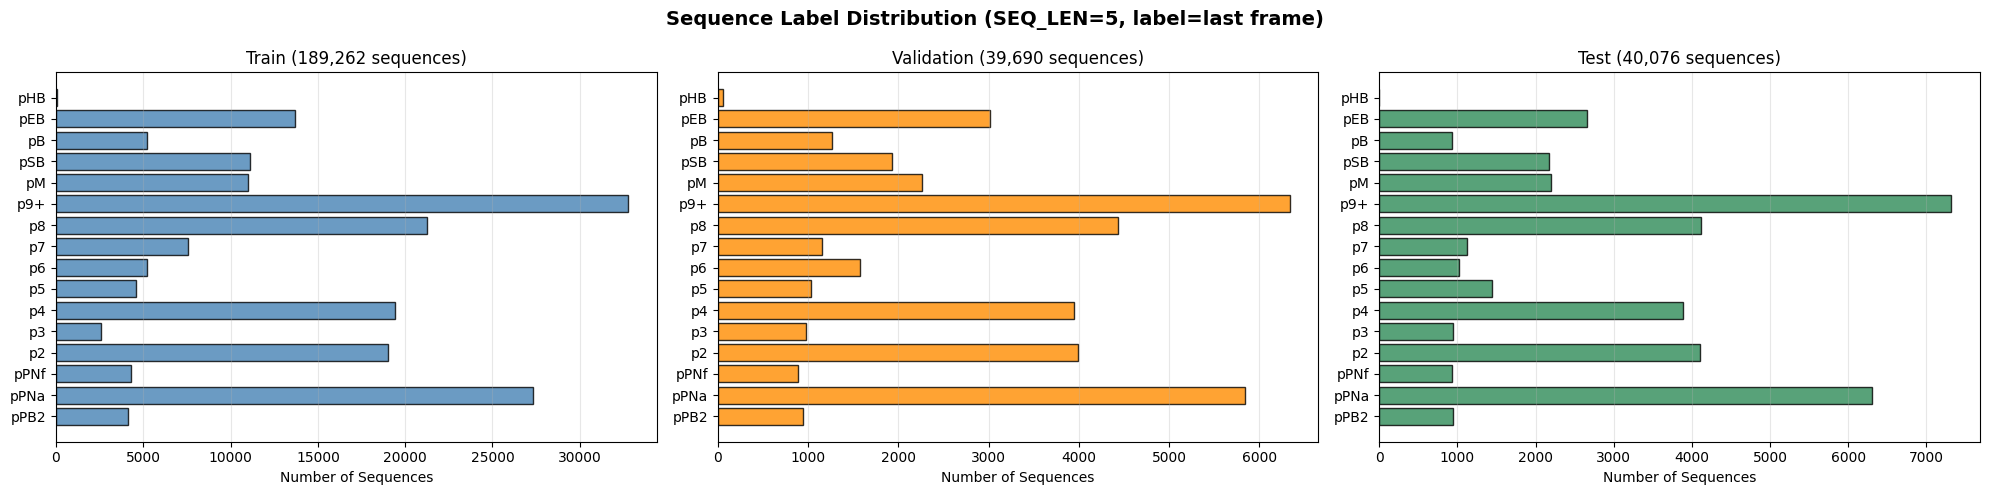

Saved class distribution plot


In [ ]:
# plotting class distribution of sequence labels
def get_label_counts(seqs_dict):
    counts = {p: 0 for p in PHASE_LABELS}
    for frames in seqs_dict.values():
        for i in range(len(frames) - SEQ_LEN + 1):
            last_frame = frames[i + SEQ_LEN - 1]
            counts[last_frame['label_str']] += 1
    return counts

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (seqs_d, title, col) in zip(axes, [
    (train_seqs, 'Train',      'steelblue'),
    (val_seqs,   'Validation', 'darkorange'),
    (test_seqs,  'Test',       'seagreen'),
]):
    counts = get_label_counts(seqs_d)
    vals   = [counts[p] for p in PHASE_LABELS]
    ax.barh(PHASE_LABELS, vals, color=col, edgecolor='black', alpha=0.8)
    ax.set_title(f'{title} ({sum(vals):,} sequences)', fontsize=12)
    ax.set_xlabel('Number of Sequences')
    ax.grid(True, axis='x', alpha=0.3)
plt.suptitle(f'Sequence Label Distribution (SEQ_LEN={SEQ_LEN}, label=last frame)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'lstm_class_distribution.png'), dpi=150)
plt.show()
print('Saved class distribution plot')

In [ ]:
# STEP: SEQUENCE DATA PIPELINE

AUTOTUNE = tf.data.AUTOTUNE

def load_image_tensor(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [IMG_H, IMG_W])
    img = tf.cast(img, tf.float32) / 255.0
    return img

def augment_sequence(frames_tensor, label):

    # Horizontal flip — same decision for all frames
    flip = tf.random.uniform([], 0, 1) > 0.5
    frames_tensor = tf.cond(
        flip,
        lambda: tf.image.flip_left_right(frames_tensor),
        lambda: frames_tensor
    )
    # Brightness — same delta for all frames
    delta = tf.random.uniform([], -0.08, 0.08)
    frames_tensor = tf.clip_by_value(frames_tensor + delta, 0.0, 1.0)

    return frames_tensor, label

def make_sequence_dataset(seqs_dict, batch_size, augment=False, shuffle=True):
    all_path_groups = []   # each entry: ([path1,...,path_n], label_int)
    all_labels      = []

    for embryo_id in sorted(seqs_dict.keys()):
        frames = seqs_dict[embryo_id]
        for i in range(len(frames) - SEQ_LEN + 1):
            window      = frames[i : i + SEQ_LEN]
            paths       = [f['image_path'] for f in window]
            label       = window[-1]['label_idx']
            all_path_groups.append(paths)
            all_labels.append(label)

    all_path_groups = np.array(all_path_groups)
    all_labels      = np.array(all_labels, dtype=np.int32)

    print(f'  Dataset: {len(all_labels):,} sequences, '
          f'each ({SEQ_LEN} x {IMG_H}x{IMG_W}x3)')

    # tf.data pipeline
    def load_sequence(paths, label):
        # paths shape: (SEQ_LEN,)
        frames = tf.map_fn(
            load_image_tensor,
            paths,
            fn_output_signature=tf.TensorSpec([IMG_H, IMG_W, 3], tf.float32),
            parallel_iterations=SEQ_LEN
        )
        return frames, label  # (SEQ_LEN, H, W, 3), ()

    ds = tf.data.Dataset.from_tensor_slices((all_path_groups, all_labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(all_labels), 5000), seed=SEED)
    ds = ds.map(load_sequence, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(augment_sequence, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

# smoke test on a tiny subset
print('Building smoke-test dataset...')
tiny = {k: v for k, v in list(train_seqs.items())[:3]}
_ds  = make_sequence_dataset(tiny, batch_size=4, augment=True)
for _x, _y in _ds.take(1):
    print(f'  Sequence batch shape : {_x.shape}')
    print(f'    → expect ({min(4, count_sequences(tiny))}, {SEQ_LEN}, {IMG_H}, {IMG_W}, 3)')
    print(f'  Label batch shape    : {_y.shape}')
    print(f'  Pixel range          : [{_x.numpy().min():.3f}, {_x.numpy().max():.3f}]')
    print(f'  Label values         : {_y.numpy()}')
print('\n Sequence pipeline working!')

Building smoke-test dataset...
  Dataset: 1,265 sequences, each (5 x 112x112x3)
  Sequence batch shape : (4, 5, 112, 112, 3)
    → expect (4, 5, 112, 112, 3)
  Label batch shape    : (4,)
  Pixel range          : [0.000, 0.791]
  Label values         : [1 1 5 1]

 Sequence pipeline working!


In [ ]:
# STEP: CUSTOM LOSS FUNCTION

class CustomEmbryoLoss(tf.keras.losses.Loss):
    """
    same ordinal-aware loss as Assignment 4.
    L_total = L_CCE + lambda1 * L_DL + lambda2 * L_PL

    L_DL: squared expected ordinal distance — penalises predictions
          whose probability mass is spread far from true class
    L_PL: piecewise penalty (linear near, quadratic far from true class)

    All 3 properties hold: monotonically increasing, piecewise
    differentiable, faster convergence (large gradients for distant errors).
    """
    def __init__(self, num_classes=NUM_CLASSES,
                 lambda1=LAMBDA1, lambda2=LAMBDA2,
                 delta=DELTA, alpha=ALPHA_PL, beta=BETA_PL,
                 name='custom_embryo_loss'):
        super().__init__(name=name)
        self.num_classes = num_classes
        self.lambda1     = tf.constant(lambda1, tf.float32)
        self.lambda2     = tf.constant(lambda2, tf.float32)
        self.delta       = tf.constant(float(delta), tf.float32)
        self.alpha       = tf.constant(alpha, tf.float32)
        self.beta        = tf.constant(beta,  tf.float32)
        self.class_idx   = tf.cast(tf.range(num_classes), tf.float32)

    def _cce(self, y_true_oh, y_pred):
        return -tf.reduce_sum(y_true_oh * tf.math.log(y_pred + 1e-7), axis=-1)

    def _distance_loss(self, y_true_f, y_pred):
        dist = tf.abs(self.class_idx - tf.expand_dims(y_true_f, 1))
        D    = tf.reduce_sum(y_pred * dist, axis=1)
        return tf.square(D)

    def _penalty_loss(self, y_true_f, y_pred):
        dist = tf.abs(self.class_idx - tf.expand_dims(y_true_f, 1))
        W    = (tf.cast(dist <= self.delta, tf.float32) * self.alpha * dist +
                tf.cast(dist >  self.delta, tf.float32) * self.beta  * tf.square(dist))
        return tf.reduce_sum(y_pred * W, axis=1)

    def call(self, y_true, y_pred):
        y_true    = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred    = tf.cast(y_pred, tf.float32)
        y_true_oh = tf.one_hot(y_true, self.num_classes)
        y_true_f  = tf.cast(y_true, tf.float32)
        total = (self._cce(y_true_oh, y_pred)
                 + self.lambda1 * self._distance_loss(y_true_f, y_pred)
                 + self.lambda2 * self._penalty_loss(y_true_f, y_pred))
        return tf.reduce_mean(total)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_classes':self.num_classes,
                    'lambda1':float(self.lambda1),'lambda2':float(self.lambda2),
                    'delta':float(self.delta),'alpha':float(self.alpha),
                    'beta':float(self.beta)})
        return cfg

# sanity check
_loss = CustomEmbryoLoss()
_yt   = tf.constant([0, 3, 8, 15])
_yp   = tf.nn.softmax(tf.random.normal((4, 16)))
print(f'Custom loss OK — test value: {_loss(_yt, _yp).numpy():.4f}')

Custom loss OK — test value: 56.6558


In [ ]:
# STEP: LSTM MODEL ARCHITECTURE

def print_param_count(model):
    tr  = int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))
    ntr = int(np.sum([np.prod(v.shape) for v in model.non_trainable_weights]))
    print(f'   Trainable params     : {tr:>12,}')
    print(f'   Non-trainable params : {ntr:>12,}')
    print(f'   Total params         : {tr+ntr:>12,}')

def build_cnn_lstm():
    inp = layers.Input(shape=(SEQ_LEN, IMG_H, IMG_W, 3), name='sequence_input')

    # CNN Feature Extractor
    x = layers.TimeDistributed(
            layers.Conv2D(32, 3, activation='relu', padding='same'),
            name='td_conv1')(inp)
    x = layers.TimeDistributed(
            layers.MaxPooling2D(2),
            name='td_pool1')(x)

    x = layers.TimeDistributed(
            layers.Conv2D(64, 3, activation='relu', padding='same'),
            name='td_conv2')(x)
    x = layers.TimeDistributed(
            layers.MaxPooling2D(2),
            name='td_pool2')(x)

    x = layers.TimeDistributed(
            layers.Conv2D(128, 3, activation='relu', padding='same'),
            name='td_conv3')(x)
    x = layers.TimeDistributed(
            layers.MaxPooling2D(2),
            name='td_pool3')(x)

    # Flattening spatial features to 1D vector per frame
    x = layers.TimeDistributed(
            layers.GlobalMaxPooling2D(),
            name='td_gmp')(x)

    # LSTM Sequence Processing
    x = layers.LSTM(LSTM_UNITS,
                    return_sequences=False,
                    dropout=DROPOUT_RATE,
                    recurrent_dropout=0,
                    name='lstm')(x)

    # Classification Head
    x = layers.BatchNormalization(name='bn')(x)
    x = layers.Dropout(DROPOUT_RATE, name='dropout')(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax', name='output')(x)

    model = Model(inp, out, name='CNN_LSTM')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
        loss=CustomEmbryoLoss(),
        metrics=['accuracy']
    )
    return model

with strategy.scope():
    print("Building model within MirroredStrategy scope...")
    model_cnn_lstm = build_cnn_lstm()

print('Model builder finished!')
print_param_count(model_cnn_lstm)

Building model within MirroredStrategy scope...
Model builder finished!
   Trainable params     :      492,112
   Non-trainable params :          512
   Total params         :      492,624


In [ ]:
# building model and printing model.summary()
print('Building models within MirroredStrategy scope...\n')

with strategy.scope():
    model_cnn_lstm = build_cnn_lstm()

# Visualization & Summary
for name, model in [('CNN-LSTM', model_cnn_lstm)]:
    print(f'  {name} Architecture')
    model.summary()
    print_param_count(model)
    print(f"\nReady to train on {strategy.num_replicas_in_sync} GPUs!")

Building models within MirroredStrategy scope...

  CNN-LSTM Architecture


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)     │ (None, 5, 112, 112, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_conv1 (TimeDistributed)      │ (None, 5, 112, 112,    │           896 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_pool1 (TimeDistributed)      │ (None, 5, 56, 56, 32)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_conv2 (TimeDistributed)      │ (None, 5, 56, 56, 64)  │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_pool2 (TimeDistributed)      │ (None, 5, 28, 28, 64)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_conv3 (TimeDistributed)      │ (None, 5, 28, 28, 128) │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_pool3 (TimeDistributed)      │ (None, 5, 14, 14, 128) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_gmp (TimeDistributed)        │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 492,624 (1.88 MB)

 Trainable params: 492,112 (1.88 MB)

 Non-trainable params: 512 (2.00 KB)

   Trainable params     :      492,112
   Non-trainable params :          512
   Total params         :      492,624

Ready to train on 2 GPUs!


In [ ]:
print('Building training dataset...')
train_ds = make_sequence_dataset(train_seqs, BATCH_SIZE, augment=True,  shuffle=True)

print('Building validation dataset...')
val_ds   = make_sequence_dataset(val_seqs,   BATCH_SIZE, augment=False, shuffle=False)

print('Building test dataset...')
test_ds  = make_sequence_dataset(test_seqs,  BATCH_SIZE, augment=False, shuffle=False)

print('\n All datasets ready!')

Building training dataset...
  Dataset: 189,262 sequences, each (5 x 112x112x3)
Building validation dataset...
  Dataset: 39,690 sequences, each (5 x 112x112x3)
Building test dataset...
  Dataset: 40,076 sequences, each (5 x 112x112x3)

 All datasets ready!


In [ ]:
def train_model(model, name, train_data, val_data):
    print(f"Starting training for: {name}")

    # 1. Path for saving weights in Kaggle's output folder
    ckpt_path = os.path.join(SAVE_DIR, f'best_{name.lower()}_model.keras')

    # 2. Callbacks
    callbacks = [
        ModelCheckpoint(
            ckpt_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

    # 3. Execution
    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    hist_path = os.path.join(SAVE_DIR, f'history_{name.lower()}.json')
    with open(hist_path, 'w') as f:
        json.dump(history.history, f)

    print(f"{name} training finished. Best model saved to: {ckpt_path}")
    return history

history_cnn_lstm = train_model(model_cnn_lstm, 'CNN_LSTM', train_ds, val_ds)

Starting training for: CNN_LSTM
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/devic

I0000 00:00:1776935838.856127     179 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776935840.136494     178 cuda_dnn.cc:529] Loaded cuDNN version 91002


5915/5915 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.1537 - loss: 37.2257INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_accuracy improved from -inf to 0.37863, saving model to /kaggle/working/results/best_cnn_lstm_model.keras
5915/5915 ━━━━━━━━━━━━━━━━━━━━ 870s 146ms/step - accuracy: 0.1537 - loss: 37.2237 - val_accuracy: 0.3786 - val_loss: 15.4262 - learning_rate: 1.0000e-04
Epoch 2/30
5914/5915 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.3459 - loss: 13.7172
Epoch 2: val_accuracy improved from 0.37863 to 0.43973, saving model to /kaggle/working/results/best_cnn_lstm_model.keras
5915/5915 ━━━━━━━━━━━━━━━━━━━━ 845s 143ms/step - accuracy: 0.3459 - loss: 13.7166 - val_accuracy: 0.4397 - val_loss: 11.5450 - learning_rate: 1.0000e-04
Ep


 Starting Final Evaluation for CNN-LSTM...
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 130s 104ms/step - accuracy: 0.5562 - loss: 7.6661
Generating predictions for CNN-LSTM...
1253/1253 ━━━━━━━━━━━━━━━━━━━━ 126s 100ms/step

 CNN-LSTM Results Summary:
Loss: 8.2885 | Acc: 58.16% | F1: 0.5460
              precision    recall  f1-score   support

        pPB2      0.000     0.000     0.000       948
        pPNa      0.714     0.950     0.815      6304
        pPNf      0.000     0.000     0.000       927
          p2      0.716     0.779     0.746      4097
          p3      0.000     0.000     0.000       947
          p4      0.563     0.645     0.601      3888
          p5      0.154     0.060     0.087      1441
          p6      0.202     0.228     0.214      1024
          p7      0.073     0.081     0.077      1116
          p8      0.438     0.582     0.500      4115
         p9+      0.709     0.595     0.647      7319
          pM      0.465     0.448     0.456      2192
         pSB      

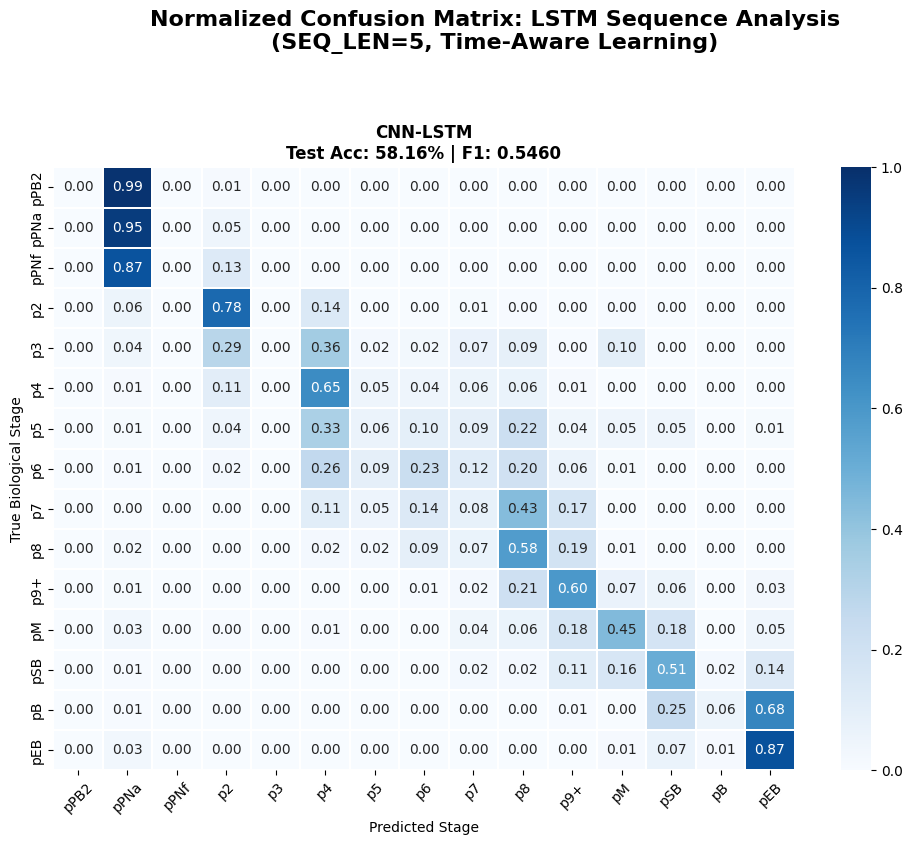

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import os

# 1. Evaluating model on test set
results = {}
eval_list = [('CNN-LSTM', model_cnn_lstm)]

for name, model in eval_list:
    print(f'\n Starting Final Evaluation for {name}...')

    loss_v, acc_v = model.evaluate(test_ds, verbose=1)

    print(f"Generating predictions for {name}...")
    preds_probs = model.predict(test_ds, verbose=1)
    y_pred = np.argmax(preds_probs, axis=1)

    y_true = np.concatenate([y for x, y in test_ds], axis=0)

    # Weighted F1 Score
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    results[name] = dict(loss=loss_v, acc=acc_v, f1=f1, y_pred=y_pred, y_true=y_true)

    print(f'\n {name} Results Summary:')
    print(f'Loss: {loss_v:.4f} | Acc: {acc_v*100:.2f}% | F1: {f1:.4f}')

    unique_labels_present = np.unique(np.concatenate([y_true, y_pred]))
    unique_labels_present = sorted(unique_labels_present.tolist())
    present_phase_names = [PHASE_LABELS[i] for i in unique_labels_present]

    print(classification_report(y_true, y_pred,
                                labels=unique_labels_present,
                                target_names=present_phase_names,
                                digits=3))

# 2. Confusion Matrices Plotting
num_models = len(results)
fig, axes = plt.subplots(1, num_models, figsize=(10 * num_models, 8), squeeze=False)
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    cm = confusion_matrix(res['y_true'], res['y_pred'])

    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-7)

    labels_in_test = np.unique(res['y_true'])
    tick_labels = [PHASE_LABELS[j] for j in labels_in_test]

    sns.heatmap(cm_norm, ax=ax,
                xticklabels=tick_labels, yticklabels=tick_labels,
                cmap='Blues', vmin=0, vmax=1, linewidths=0.3, annot=True, fmt=".2f")

    ax.set_title(f"{name}\nTest Acc: {res['acc']*100:.2f}% | F1: {res['f1']:.4f}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Stage')
    ax.set_ylabel('True Biological Stage')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(f'Normalized Confusion Matrix: LSTM Sequence Analysis\n(SEQ_LEN={SEQ_LEN}, Time-Aware Learning)',
             fontsize=16, y=1.05, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'lstm_confusion_matrices_final.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
print(f'\n Evaluation complete! Plot saved to: {save_path}')
plt.show()

Processing 201 windows for embryo AA83-7...


Generating Plot: 100%|██████████| 201/201 [00:16<00:00, 12.08it/s]


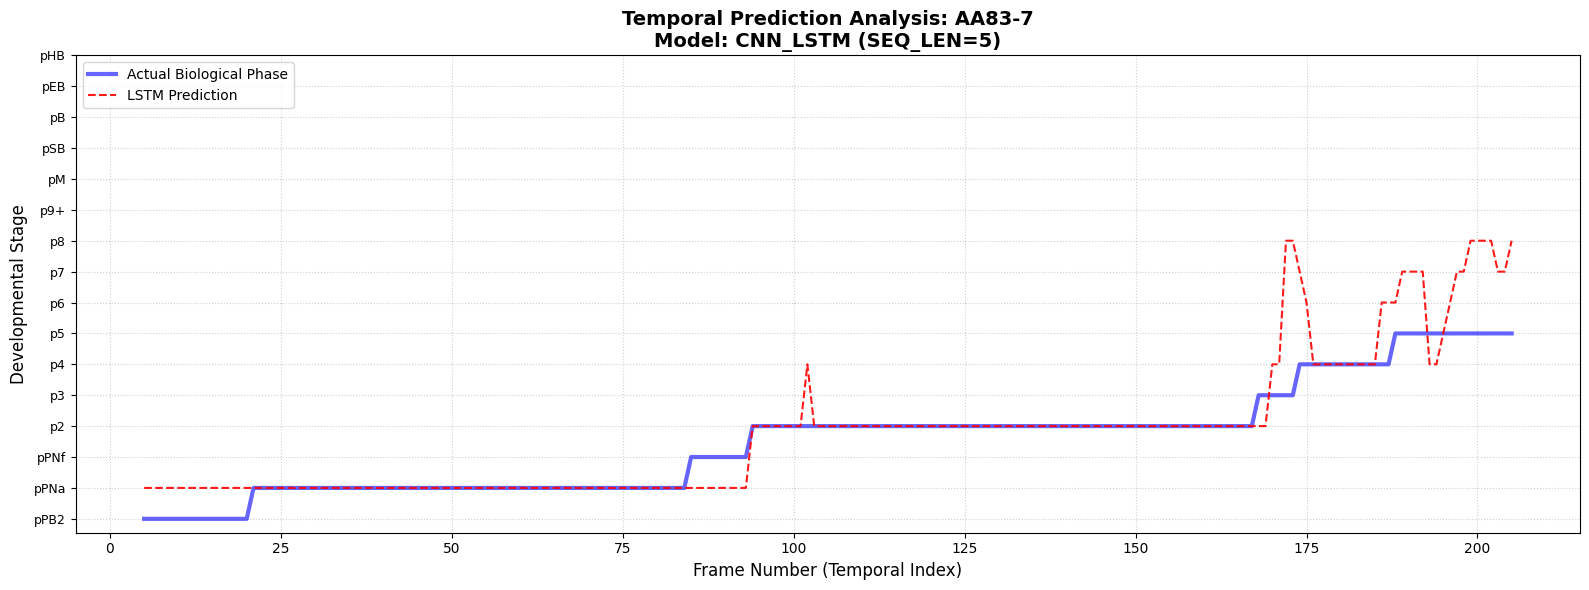

Plot saved as: temporal_analysis_AA83-7.png


In [ ]:
def visualise_temporal_predictions(model, model_name, embryo_id, seqs_dict, max_frames=200):
    if embryo_id not in seqs_dict:
        print(f'{embryo_id} not in this split')
        return

    frames = seqs_dict[embryo_id]
    if len(frames) < SEQ_LEN:
        return

    if len(frames) > max_frames + SEQ_LEN:
        frames = frames[:max_frames + SEQ_LEN]

    true_labels = []
    pred_labels = []

    print(f"Processing {len(frames) - SEQ_LEN + 1} windows for embryo {embryo_id}...")

    for i in tqdm(range(len(frames) - SEQ_LEN + 1), desc="Generating Plot"):
        window = frames[i : i + SEQ_LEN]
        paths  = [f['image_path'] for f in window]
        label  = window[-1]['label_idx']

        seq_imgs = []
        for p in paths:
            img = load_image_tensor(p)
            seq_imgs.append(img)

        seq_tensor = tf.expand_dims(tf.stack(seq_imgs), 0)

        pred = model(seq_tensor, training=False).numpy()[0]
        pred_label = np.argmax(pred)

        true_labels.append(label)
        pred_labels.append(pred_label)

    frame_nums = list(range(SEQ_LEN, len(frames) + 1))

    # Plotting
    fig, ax = plt.subplots(figsize=(16, 6))

    # Plotting true stages
    ax.plot(frame_nums, true_labels, 'b-', lw=3, label='Actual Biological Phase', alpha=0.6)

    # Plotting predicted stages
    ax.plot(frame_nums, pred_labels, 'r--', lw=1.5, label='LSTM Prediction', alpha=0.9)

    # Formatting the Y-axis with the Phase Labels
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_yticklabels(PHASE_LABELS, fontsize=9)

    ax.set_xlabel('Frame Number (Temporal Index)', fontsize=12)
    ax.set_ylabel('Developmental Stage', fontsize=12)
    ax.set_title(f'Temporal Prediction Analysis: {embryo_id}\nModel: {model_name} (SEQ_LEN={SEQ_LEN})',
                 fontsize=14, fontweight='bold')

    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()

    # Saving to Kaggle Working Directory
    save_name = f'temporal_analysis_{embryo_id}.png'
    plt.savefig(os.path.join(SAVE_DIR, save_name), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Plot saved as: {save_name}')

# Execution
sample_test_embryo = sorted(test_seqs.keys())[0]
visualise_temporal_predictions(model_cnn_lstm, 'CNN_LSTM', sample_test_embryo, test_seqs)

In [ ]:
for name, model in [
    ('CNN_LSTM',         model_cnn_lstm),
]:
    path = os.path.join(SAVE_DIR, f'{name}_final.keras')
    model.save(path)
    print(f'Saved: {path}')

print('\nAll files in SAVE_DIR:')
for f in sorted(os.listdir(SAVE_DIR)):
    sz = os.path.getsize(os.path.join(SAVE_DIR, f)) / 1e6
    print(f'  {f:<50} {sz:.1f} MB')

Saved: /kaggle/working/results/CNN_LSTM_final.keras

All files in SAVE_DIR:
  CNN_LSTM_final.keras                               6.0 MB
  best_cnn_lstm_model.keras                          6.0 MB
  history_cnn_lstm.json                              0.0 MB
  lstm_class_distribution.png                        0.1 MB
  lstm_confusion_matrices_final.png                  0.3 MB
  temporal_analysis_AA83-7.png                       0.1 MB
